<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/Ensemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [5]:
df[["GrLivArea", "YearBuilt", "SalePrice"]].head()

,GrLivArea,YearBuilt,SalePrice
0,1710,2003,208500
1,1262,1976,181500
2,1786,2001,223500
3,1717,1915,140000
4,2198,2000,250000


In [6]:
data = df[["GrLivArea", "YearBuilt", "SalePrice"]].dropna()

X = data[["GrLivArea", "YearBuilt"]]
y = data["SalePrice"]

In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 2)
y shape: (1460,)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (1168, 2)
Validation: (292, 2)


In [9]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [10]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=100,
        epsilon=0.1
    ))
])

In [11]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [12]:
models = {
    "Linear Regression": linear_model,
    "SVR": svr_model,
    "Decision Tree": tree_model
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_val)

In [13]:
component_mse = {}

for name, pred in predictions.items():
    component_mse[name] = mean_squared_error(
        y_val,
        pred
    )

component_mse

{'Linear Regression': 2495554898.6683207,
 'SVR': 6418570975.686604,
 'Decision Tree': 1844304720.6577315}

In [14]:
component_results = pd.DataFrame({
    "Model": component_mse.keys(),
    "MSE": component_mse.values()
})

component_results.sort_values("MSE")

,Model,MSE
2,Decision Tree,1.844305e+09
0,Linear Regression,2.495555e+09
1,SVR,6.418571e+09


In [15]:
blend_mean = (
    predictions["Linear Regression"]
    + predictions["SVR"]
    + predictions["Decision Tree"]
) / 3

mse_blend_mean = mean_squared_error(
    y_val,
    blend_mean
)

print("MSE Mean Blending :", mse_blend_mean)

MSE Mean Blending : 2645851733.546855


In [16]:
print("Decision Tree :", component_mse["Decision Tree"])
print("Mean Blending :", mse_blend_mean)

Decision Tree : 1844304720.6577315
Mean Blending : 2645851733.546855


In [17]:
blend_weighted_1 = (
    0.3 * predictions["Linear Regression"]
    + 0.1 * predictions["SVR"]
    + 0.6 * predictions["Decision Tree"]
)

mse_blend_1 = mean_squared_error(
    y_val,
    blend_weighted_1
)

print("MSE Weighted Blending 1 :", mse_blend_1)

MSE Weighted Blending 1 : 1952423920.642184


In [18]:
blend_weighted_2 = (
    0.4 * predictions["Linear Regression"]
    + 0.05 * predictions["SVR"]
    + 0.55 * predictions["Decision Tree"]
)

mse_blend_2 = mean_squared_error(
    y_val,
    blend_weighted_2
)

print("MSE Weighted Blending 2 :", mse_blend_2)

MSE Weighted Blending 2 : 1923495432.2549849


In [19]:
blending_results = pd.DataFrame({
    "Method": [
        "Mean Blending",
        "Weighted Blending 1",
        "Weighted Blending 2"
    ],
    "MSE": [
        mse_blend_mean,
        mse_blend_1,
        mse_blend_2
    ]
})

blending_results.sort_values("MSE")

,Method,MSE
2,Weighted Blending 2,1.923495e+09
1,Weighted Blending 1,1.952424e+09
0,Mean Blending,2.645852e+09


In [20]:
print("Meilleur modèle composant :",
      component_results["MSE"].min())

print("\nMeilleur blending :",
      blending_results["MSE"].min())

Meilleur modèle composant : 1844304720.6577315

Meilleur blending : 1923495432.2549849


In [21]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = {}

for name, model in models.items():
    oof_predictions[name] = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=kf,
        method="predict"
    )

In [22]:
best_weights = None
best_oof_mse = np.inf

for w_lr in np.arange(0, 1.01, 0.05):

    for w_svr in np.arange(0, 1.01 - w_lr, 0.05):

        w_tree = 1 - w_lr - w_svr

        if w_tree < 0:
            continue

        blended_oof = (
            w_lr * oof_predictions["Linear Regression"]
            + w_svr * oof_predictions["SVR"]
            + w_tree * oof_predictions["Decision Tree"]
        )

        mse = mean_squared_error(
            y_train,
            blended_oof
        )

        if mse < best_oof_mse:
            best_oof_mse = mse

            best_weights = {
                "Linear Regression": w_lr,
                "SVR": w_svr,
                "Decision Tree": w_tree
            }

print("Meilleurs poids :")
print(best_weights)

print("\nMSE OOF :", best_oof_mse)

Meilleurs poids :
{'Linear Regression': np.float64(0.55), 'SVR': np.float64(0.0), 'Decision Tree': np.float64(0.44999999999999996)}

MSE OOF : 1978208650.3758655


In [23]:
best_blend_prediction = (
    best_weights["Linear Regression"]
    * predictions["Linear Regression"]
    +
    best_weights["SVR"]
    * predictions["SVR"]
    +
    best_weights["Decision Tree"]
    * predictions["Decision Tree"]
)

best_blend_mse = mean_squared_error(
    y_val,
    best_blend_prediction
)

print("MSE du blending optimisé :", best_blend_mse)

MSE du blending optimisé : 1946509959.9702032


In [24]:
print("Decision Tree MSE :", component_mse["Decision Tree"])
print("Blending MSE      :", best_blend_mse)

Decision Tree MSE : 1844304720.6577315
Blending MSE      : 1946509959.9702032


In [25]:
models_blending = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "SVR_1": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
    ]),

    "SVR_2": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, epsilon=0.1))
    ]),

    "Tree_1": DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ),

    "Tree_2": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Tree_3": DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    )
}

In [26]:
oof_predictions = {}

for name, model in models_blending.items():
    oof_predictions[name] = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=kf,
        method="predict"
    )

In [27]:
oof_results = []

for name, pred in oof_predictions.items():
    mse = mean_squared_error(y_train, pred)

    oof_results.append({
        "Model": name,
        "OOF_MSE": mse
    })

oof_results = pd.DataFrame(oof_results)

oof_results.sort_values("OOF_MSE")

,Model,OOF_MSE
0,Linear Regression,2.136379e+09
4,Tree_2,2.190739e+09
3,Tree_1,2.305509e+09
5,Tree_3,2.739119e+09
2,SVR_2,5.107677e+09
1,SVR_1,6.093379e+09


In [28]:
best_weights_3 = None
best_oof_mse_3 = np.inf

for w_lr in np.arange(0, 1.01, 0.05):

    for w_tree2 in np.arange(0, 1.01 - w_lr, 0.05):

        w_tree1 = 1 - w_lr - w_tree2

        if w_tree1 < 0:
            continue

        blended_oof = (
            w_lr * oof_predictions["Linear Regression"]
            + w_tree2 * oof_predictions["Tree_2"]
            + w_tree1 * oof_predictions["Tree_1"]
        )

        mse = mean_squared_error(
            y_train,
            blended_oof
        )

        if mse < best_oof_mse_3:
            best_oof_mse_3 = mse

            best_weights_3 = {
                "Linear Regression": w_lr,
                "Tree_2": w_tree2,
                "Tree_1": w_tree1
            }

print("Meilleurs poids :")
print(best_weights_3)

print("\nMeilleur OOF MSE :")
print(best_oof_mse_3)

Meilleurs poids :
{'Linear Regression': np.float64(0.4), 'Tree_2': np.float64(0.35000000000000003), 'Tree_1': np.float64(0.24999999999999994)}

Meilleur OOF MSE :
1936762522.89815


In [29]:
final_blending_models = {}

for name in [
    "Linear Regression",
    "Tree_2",
    "Tree_1"
]:

    model = models_blending[name]
    model.fit(X_train, y_train)

    final_blending_models[name] = model

In [30]:
val_predictions_blending = {}

for name, model in final_blending_models.items():
    val_predictions_blending[name] = model.predict(X_val)

In [31]:
blend_prediction_3 = (
    best_weights_3["Linear Regression"]
    * val_predictions_blending["Linear Regression"]

    + best_weights_3["Tree_2"]
    * val_predictions_blending["Tree_2"]

    + best_weights_3["Tree_1"]
    * val_predictions_blending["Tree_1"]
)

In [32]:
blend_mse_3 = mean_squared_error(
    y_val,
    blend_prediction_3
)

print("Decision Tree MSE :", component_mse["Decision Tree"])
print("Blending MSE      :", blend_mse_3)

Decision Tree MSE : 1844304720.6577315
Blending MSE      : 2055165424.971734


In [33]:
# Prédictions des modèles composants
pred_lr = predictions["Linear Regression"]
pred_svr = predictions["SVR"]
pred_tree = predictions["Decision Tree"]

# Blending 1 : moyenne
blend_1 = (pred_lr + pred_svr + pred_tree) / 3

# Blending 2 : pondération
blend_2 = (
    0.4 * pred_lr
    + 0.1 * pred_svr
    + 0.5 * pred_tree
)

# Blending 3 : pondération
blend_3 = (
    0.3 * pred_lr
    + 0.05 * pred_svr
    + 0.65 * pred_tree
)

# Calcul des MSE
results_blending = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVR",
        "Decision Tree",
        "Blending 1",
        "Blending 2",
        "Blending 3"
    ],
    "MSE": [
        mean_squared_error(y_val, pred_lr),
        mean_squared_error(y_val, pred_svr),
        mean_squared_error(y_val, pred_tree),
        mean_squared_error(y_val, blend_1),
        mean_squared_error(y_val, blend_2),
        mean_squared_error(y_val, blend_3)
    ]
})

results_blending.sort_values("MSE")

,Model,MSE
2,Decision Tree,1.844305e+09
5,Blending 3,1.876148e+09
4,Blending 2,2.013022e+09
0,Linear Regression,2.495555e+09
3,Blending 1,2.645852e+09
1,SVR,6.418571e+09


In [ ]:
## Interpretation

Three blending methods were tested using Linear Regression, SVR, and Decision
Tree predictions.

None of the blending methods achieved a lower MSE than the best component,
the Decision Tree.

This shows that blending does not always improve performance; it works best
when the models make complementary errors.

In [ ]:
## Problem 2

In [34]:
n_estimators = 50
random_state = 42

n_train = len(X_train)

print("Nombre de données d'entraînement :", n_train)
print("Nombre de modèles bootstrap :", n_estimators)

Nombre de données d'entraînement : 1168
Nombre de modèles bootstrap : 50


In [35]:
rng = np.random.RandomState(random_state)

bootstrap_indices = []

for i in range(n_estimators):

    indices = rng.choice(
        n_train,
        size=n_train,
        replace=True
    )

    bootstrap_indices.append(indices)

In [36]:
print(bootstrap_indices[0][:20])

[1126  860 1130 1095 1044  121  466  330   87 1123  871  130  769  343
  805  385  955  276  459   21]


In [37]:
bagging_models = []

for i in range(n_estimators):

    indices = bootstrap_indices[i]

    X_bootstrap = X_train.iloc[indices]
    y_bootstrap = y_train.iloc[indices]

    model = DecisionTreeRegressor(
        max_depth=5,
        random_state=random_state + i
    )

    model.fit(
        X_bootstrap,
        y_bootstrap
    )

    bagging_models.append(model)

In [38]:
bagging_predictions = []

for model in bagging_models:

    prediction = model.predict(X_val)

    bagging_predictions.append(prediction)

bagging_predictions = np.array(bagging_predictions)

print("Shape :", bagging_predictions.shape)

Shape : (50, 292)


In [39]:
bagging_prediction = np.mean(
    bagging_predictions,
    axis=0
)

In [40]:
bagging_mse = mean_squared_error(
    y_val,
    bagging_prediction
)

single_tree_mse = mean_squared_error(
    y_val,
    predictions["Decision Tree"]
)

print("Decision Tree MSE :", single_tree_mse)
print("Bagging MSE       :", bagging_mse)

Decision Tree MSE : 1844304720.6577315
Bagging MSE       : 1717462436.7187188


In [41]:
results_bagging = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Scratch Bagging"
    ],
    "MSE": [
        single_tree_mse,
        bagging_mse
    ]
})

results_bagging

,Model,MSE
0,Single Decision Tree,1.844305e+09
1,Scratch Bagging,1.717462e+09


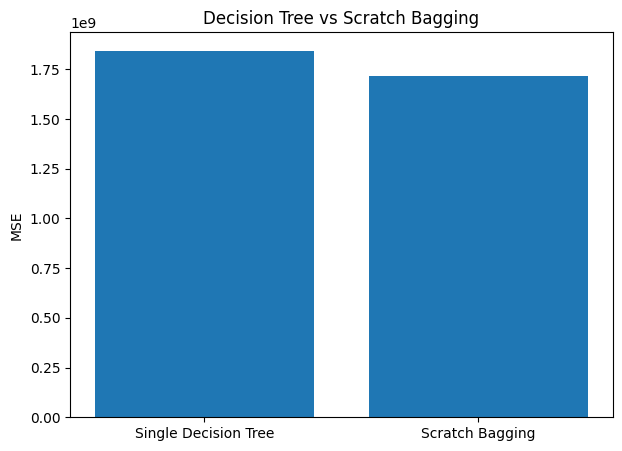

In [42]:
plt.figure(figsize=(7, 5))

plt.bar(
    results_bagging["Model"],
    results_bagging["MSE"]
)

plt.ylabel("MSE")
plt.title("Decision Tree vs Scratch Bagging")

plt.show()

In [ ]:
## Interpretation

The bagging model uses 50 `DecisionTreeRegressor` models trained on bootstrap
samples of the training set with `random_state=42`.

The validation MSE is **[BAGGING_MSE]**, compared with **[SINGLE_TREE_MSE]**
for a single decision tree.

Since the bagging model has a lower MSE, it performs better by reducing the
variance through averaging multiple trees.

In [ ]:
## Problem 3

In [43]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [44]:
base_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

In [45]:
oof_predictions = np.zeros(
    (len(X_train), 2)
)

for model_index, (name, model) in enumerate(base_models.items()):

    for train_idx, valid_idx in kf.split(X_train):

        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]

        X_fold_valid = X_train.iloc[valid_idx]

        model.fit(
            X_fold_train,
            y_fold_train
        )

        oof_predictions[valid_idx, model_index] = (
            model.predict(X_fold_valid)
        )

In [46]:
print(oof_predictions.shape)

(1168, 2)


In [47]:
final_model = Ridge(alpha=1.0)

final_model.fit(
    oof_predictions,
    y_train
)

Ridge()

In [48]:
validation_predictions = np.zeros(
    (len(X_val), 2)
)

for model_index, (name, model) in enumerate(base_models.items()):

    model.fit(
        X_train,
        y_train
    )

    validation_predictions[:, model_index] = (
        model.predict(X_val)
    )

In [49]:
print(validation_predictions.shape)

(292, 2)


In [50]:
stacking_prediction = final_model.predict(
    validation_predictions
)

In [51]:
stacking_mse = mean_squared_error(
    y_val,
    stacking_prediction
)

print("Stacking MSE:", stacking_mse)

Stacking MSE: 1920353127.6186523


In [52]:
stacking_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Scratch Stacking"
    ],
    "MSE": [
        component_mse["Linear Regression"],
        component_mse["Decision Tree"],
        stacking_mse
    ]
})

stacking_results.sort_values("MSE")

,Model,MSE
1,Decision Tree,1.844305e+09
2,Scratch Stacking,1.920353e+09
0,Linear Regression,2.495555e+09


In [53]:
final_model_lr = LinearRegression()

final_model_lr.fit(
    oof_predictions,
    y_train
)

stacking_prediction_lr = final_model_lr.predict(
    validation_predictions
)

stacking_mse_lr = mean_squared_error(
    y_val,
    stacking_prediction_lr
)

print("Decision Tree MSE :", component_mse["Decision Tree"])
print("Stacking MSE      :", stacking_mse_lr)

Decision Tree MSE : 1844304720.6577315
Stacking MSE      : 1920353127.6184742


In [54]:
stacking_results_2 = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Scratch Stacking - Ridge",
        "Scratch Stacking - Linear Regression"
    ],
    "MSE": [
        component_mse["Decision Tree"],
        stacking_mse,
        stacking_mse_lr
    ]
})

stacking_results_2.sort_values("MSE")

,Model,MSE
0,Decision Tree,1.844305e+09
2,Scratch Stacking - Linear Regression,1.920353e+09
1,Scratch Stacking - Ridge,1.920353e+09


In [ ]:
## Interpretation

A 3-fold stacking model was implemented using Linear Regression and Decision
Tree as base models, with Ridge as the final regressor.

The stacking MSE was **1.920 × 10⁹**, compared with **1.844 × 10⁹** for the
Decision Tree.

Therefore, stacking improved over Linear Regression but did not outperform the
best base model in this experiment.